In [1]:
import pandas as pd
import numpy as np

In [2]:
train_flag = pd.read_csv(r"C:\Users\aarav\OneDrive\Desktop\senior_ds_test\data\train\train_flag.csv")

In [3]:
train_flag

,uid,NAME_CONTRACT_TYPE,TARGET
0,XDA69787158,Cash loans,0
1,BSE47789733,Cash loans,0
2,NTJ92213825,Cash loans,0
3,TCQ47571695,Cash loans,0
4,WJZ68772744,Cash loans,0
...,...,...,...
261378,BAO14050568,Cash loans,0
261379,NDO00278120,Cash loans,0
261380,LDY78194712,Cash loans,0
261381,EVH98380736,Revolving loans,0


In [4]:
train_flag.shape

(261383, 3)

In [5]:
acc_raw = pd.read_json(r"C:\Users\aarav\OneDrive\Desktop\senior_ds_test\data\train\accounts_data_train.json")

In [6]:
acc_raw

,0,1,2,3,4,5,6,7,8,9,...,106,107,108,109,110,111,112,113,114,115
0,"{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...",None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,"{'credit_type': 'Credit card', 'loan_amount': ...",None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,"{'credit_type': 'Consumer credit', 'loan_amoun...",None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,"{'credit_type': 'Credit card', 'loan_amount': ...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Credit card', 'loan_amount': ...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Credit card', 'loan_amount': ...",None,None,...,None,None,None,None,None,None,None,None,None,None
4,"{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Credit card', 'loan_amount': ...",None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223913,"{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...",None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
223914,"{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...",None,None,None,...,None,None,None,None,None,None,None,None,None,None
223915,"{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Consumer credit', 'loan_amoun...",None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
223916,"{'credit_type': 'Credit card', 'loan_amount': ...","{'credit_type': 'Consumer credit', 'loan_amoun...","{'credit_type': 'Car loan', 'loan_amount': 252...","{'credit_type': 'Consumer credit', 'loan_amoun...",None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [7]:
acc_df = pd.json_normalize(acc_raw.stack().reset_index(drop=True))

In [8]:
acc_df

,credit_type,loan_amount,amount_overdue,open_date,closed_date,payment_hist_string,uid
0,Consumer credit,272745.000,0.0,2018-09-22,2020-02-22,0000000000000000000000100000000000000000000000...,AAA09044550
1,Consumer credit,4500.000,0.0,2018-03-08,2019-07-25,000000000000000014044000000000000000000000000000,AAA09044550
2,Credit card,80996.445,0.0,2020-06-29,None,000000000000000000,AAA10545297
3,Consumer credit,43771.500,0.0,2020-06-09,2020-09-09,000000000,AAA14112888
4,Credit card,10480.500,0.0,2014-09-10,None,0000000000000000000000000000000000000000000000...,AAA20326915
...,...,...,...,...,...,...,...
1245305,Consumer credit,100116.000,0.0,2017-05-12,2017-06-15,000,ZZZ93377613
1245306,Consumer credit,34839.000,0.0,2016-11-11,2017-12-17,000000000000000000000000000000000000000,ZZZ93377613
1245307,Consumer credit,18589.500,0.0,2015-12-10,2016-05-12,000000000000000,ZZZ93377613
1245308,Consumer credit,24997.500,0.0,2020-09-19,None,000000000,ZZZ93377613


In [9]:
enq_raw = pd.read_json(r"C:\Users\aarav\OneDrive\Desktop\senior_ds_test\data\train\enquiry_data_train.json")

In [10]:
enq_df = pd.json_normalize(enq_raw.stack().reset_index(drop=True))

In [11]:
enq_raw.shape

(261383, 69)

In [12]:
enq_df.shape

(1909926, 4)

In [13]:
train_flag['TARGET'].value_counts()

TARGET
0    240326
1     21057
Name: count, dtype: int64

In [14]:
train_flag['TARGET'].value_counts(normalize=True).round(3)

TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64

In [15]:
acc_df['open_date'] = pd.to_datetime(acc_df['open_date'])
acc_df['closed_date'] = pd.to_datetime(acc_df['closed_date'])
enq_df['enquiry_date'] = pd.to_datetime(enq_df['enquiry_date'])

In [16]:
print(acc_df['open_date'].min(), acc_df['open_date'].max())
print(acc_df['closed_date'].min(), acc_df['closed_date'].max())
print(enq_df['enquiry_date'].min(), enq_df['enquiry_date'].max())

2013-01-01 00:00:00 2021-01-01 00:00:00
1905-12-13 00:00:00 2021-01-01 00:00:00
2015-08-30 00:00:00 2021-01-01 00:00:00


In [17]:
#1905 cap
acc_df.loc[acc_df['closed_date'] < '2000-01-01', 'closed_date'] = pd.NaT

In [18]:
print(acc_df['closed_date'].min())

2012-09-03 00:00:00


In [19]:
reference_date = pd.Timestamp('2021-01-01')

In [20]:
# open loan = no closed date
acc_df['is_open'] = acc_df['closed_date'].isnull().astype(int)

In [21]:
# account age in months 
acc_df['account_age_months'] = ((reference_date - acc_df['open_date']).dt.days / 30).astype(int)

In [22]:
# loan duration (only for closed loans)
acc_df['loan_duration_months'] = ((acc_df['closed_date'] - acc_df['open_date']).dt.days / 30)

In [23]:
# recently opened in last 12 months
acc_df['opened_last_12m'] = (acc_df['open_date'] >= reference_date - pd.DateOffset(months=12)).astype(int)

In [24]:
# recently closed in last 12 months
acc_df['closed_last_12m'] = (acc_df['closed_date'] >= reference_date - pd.DateOffset(months=12)).astype(int)

In [25]:
acc_df['credit_type'].value_counts()

credit_type
Consumer credit                                 908741
Credit card                                     292422
Car loan                                         20237
Mortgage                                         13196
Microloan                                         7766
Loan for business development                     1466
Another type of loan                               732
Unknown type of loan                               374
Loan for working capital replenishment             320
Real estate loan                                    17
Cash loan (non-earmarked)                           17
Loan for the purchase of equipment                  16
Loan for purchase of shares (margin lending)         4
Interbank credit                                     1
Mobile operator loan                                 1
Name: count, dtype: int64

In [26]:
# how many different types of credit does this person have

acc_df['n_credit_types'] = acc_df.groupby('uid')['credit_type'].transform('nunique')

In [27]:
acc_df['n_credit_types']

0          1
1          1
2          1
3          1
4          2
          ..
1245305    2
1245306    2
1245307    2
1245308    2
1245309    2
Name: n_credit_types, Length: 1245310, dtype: int64

In [28]:
chunks = acc_df['payment_hist_string'].str.extractall(r'(\d{3})')

In [29]:
chunks

0
        match     
0       0      000
        1      000
        2      000
        3      000
        4      000
...            ...
1245309 5      000
        6      000
        7      000
        8      000
        9      000

[20303875 rows x 1 columns]

In [30]:
chunks[0] = chunks[0].astype(int)

In [31]:
chunks.index.names = ['row', 'month']

In [32]:
chunks.shape

(20303875, 1)

In [33]:
#days past due
acc_df['max_dpd'] = chunks[0].groupby(level='row').max()

In [34]:
acc_df['max_dpd']

0           10.0
1           44.0
2            0.0
3            0.0
4          917.0
           ...  
1245305      0.0
1245306      0.0
1245307      0.0
1245308      0.0
1245309      0.0
Name: max_dpd, Length: 1245310, dtype: float64

In [35]:
acc_df['max_dpd'].describe()

count    1.216307e+06
mean     7.205284e+00
std      4.473528e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.990000e+02
Name: max_dpd, dtype: float64

In [36]:
#clip 999, and treat > 365 days same
acc_df['max_dpd'] = acc_df['max_dpd'].clip(upper=365)

In [37]:
acc_df['max_dpd'].max()

365.0

In [38]:
acc_df['max_dpd'].isnull().sum()

29003

In [39]:
acc_df['max_dpd'] = acc_df['max_dpd'].fillna(0)

In [40]:
# average days late
acc_df['mean_dpd'] = chunks[0].groupby(level='row').mean()

In [41]:
acc_df['mean_dpd']

0            0.588235
1            3.625000
2            0.000000
3            0.000000
4          190.486842
              ...    
1245305      0.000000
1245306      0.000000
1245307      0.000000
1245308      0.000000
1245309      0.000000
Name: mean_dpd, Length: 1245310, dtype: float64

In [42]:
acc_df['mean_dpd'].describe()

count    1.216307e+06
mean     1.166596e+00
std      1.022127e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.260333e+02
Name: mean_dpd, dtype: float64

In [43]:
acc_df['mean_dpd'].isnull().sum()

29003

In [44]:
acc_df['mean_dpd'] = acc_df['mean_dpd'].fillna(0)

In [45]:
# how many months had any late payment

acc_df['total_late_months'] = (chunks[0] > 0).groupby(level='row').sum()

In [46]:
acc_df['total_late_months'].isnull().sum()

29003

In [47]:
acc_df['total_late_months'] = acc_df['total_late_months'].fillna(0)

In [48]:
# % of months that were late
acc_df['pct_late_months'] = acc_df['total_late_months'] / (chunks[0].groupby(level='row').count())

In [49]:
acc_df['pct_late_months'] = acc_df['pct_late_months'].fillna(0)

In [50]:
recent = chunks.groupby(level='row').tail(6)

In [51]:
#last 6 months max dpd
acc_df['recent_max_dpd'] = recent[0].groupby(level='row').max()

In [52]:
acc_df['recent_max_dpd'].describe()

count    1.216307e+06
mean     3.322391e+00
std      3.158293e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.990000e+02
Name: recent_max_dpd, dtype: float64

In [53]:
acc_df['recent_max_dpd'] = acc_df['recent_max_dpd'].clip(upper=180)

In [54]:
acc_df['recent_max_dpd'].max()

180.0

In [55]:
#flag 999 dpd
acc_df['has_999_dpd'] = (chunks[0] == 999).groupby(level='row').max().astype(int)

In [56]:
acc_df['has_999_dpd'].value_counts()

has_999_dpd
0.0    1215840
1.0        467
Name: count, dtype: int64

In [57]:
# months with 30+ days late
acc_df['n_30dpd'] = (chunks[0] >= 30).groupby(level='row').sum()

In [58]:
# months with 60+ days late  
acc_df['n_60dpd'] = (chunks[0] >= 60).groupby(level='row').sum()

In [59]:
# months with 90+ days late
acc_df['n_90dpd'] = (chunks[0] >= 90).groupby(level='row').sum()

In [60]:
acc_df[['n_30dpd', 'n_60dpd', 'n_90dpd']].describe()

,n_30dpd,n_60dpd,n_90dpd
count,1.216307e+06,1.216307e+06,1.216307e+06
mean,2.029307e-01,1.521803e-01,1.197650e-01
std,1.472075e+00,1.350465e+00,1.246858e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00
max,7.900000e+01,7.700000e+01,7.500000e+01


In [61]:
# last month payment
acc_df['last_month_dpd'] = chunks.groupby(level='row').tail(1)[0].groupby(level='row').max()

In [62]:
acc_df['last_month_dpd'].isnull().sum()

29003

In [63]:
acc_df['last_month_dpd'] = acc_df['last_month_dpd'].fillna(0)

In [64]:
# was last month late?
acc_df['last_month_late'] = (acc_df['last_month_dpd'] > 0).astype(int)

In [65]:
acc_df['last_month_late'] = acc_df['last_month_late'].fillna(0)

In [66]:
# last 3 months max dpd
recent_3m = chunks.groupby(level='row').tail(3)
acc_df['max_dpd_last_3m'] = recent_3m[0].groupby(level='row').max().clip(upper=365)

In [67]:
# last 6 months max dpd
recent_6m = chunks.groupby(level='row').tail(6)
acc_df['max_dpd_last_6m'] = recent_6m[0].groupby(level='row').max().clip(upper=365)

In [68]:
# last 12 months max dpd
recent_12m = chunks.groupby(level='row').tail(12)
acc_df['max_dpd_last_12m'] = recent_12m[0].groupby(level='row').max().clip(upper=365)

In [69]:
# pct late months in last 6 months
acc_df['pct_late_last_6m'] = (recent[0] > 0).groupby(level='row').mean()

In [70]:
# n_30dpd in last 6 months
acc_df['n_30dpd_last_6m'] = (recent[0] >= 30).groupby(level='row').sum()

In [71]:
# n_60dpd in last 6 months
acc_df['n_60dpd_last_6m'] = (recent[0] >= 60).groupby(level='row').sum()

In [72]:
# n_90dpd in last 6 months
acc_df['n_90dpd_last_6m'] = (recent[0] >= 90).groupby(level='row').sum()

In [73]:
acc_df.isnull().sum()

credit_type                  0
loan_amount                  3
amount_overdue               0
open_date                    0
closed_date             463036
payment_hist_string          0
uid                          0
is_open                      0
account_age_months           0
loan_duration_months    463036
opened_last_12m              0
closed_last_12m              0
n_credit_types               0
max_dpd                      0
mean_dpd                     0
total_late_months            0
pct_late_months              0
recent_max_dpd           29003
has_999_dpd              29003
n_30dpd                  29003
n_60dpd                  29003
n_90dpd                  29003
last_month_dpd               0
last_month_late              0
max_dpd_last_3m          29003
max_dpd_last_6m          29003
max_dpd_last_12m         29003
pct_late_last_6m         29003
n_30dpd_last_6m          29003
n_60dpd_last_6m          29003
n_90dpd_last_6m          29003
dtype: int64

In [74]:
acc_df['recent_max_dpd'] = acc_df['recent_max_dpd'].fillna(0)

In [75]:
acc_df['has_999_dpd'] = acc_df['has_999_dpd'].fillna(0)

In [76]:
acc_df['n_30dpd'] = acc_df['n_30dpd'].fillna(0)

In [77]:
acc_df['n_60dpd'] = acc_df['n_60dpd'].fillna(0)

In [78]:
acc_df['n_90dpd'] = acc_df['n_90dpd'].fillna(0)

In [79]:
acc_df['max_dpd_last_3m'] = acc_df['max_dpd_last_3m'].fillna(0)

In [80]:
acc_df['max_dpd_last_6m'] = acc_df['max_dpd_last_6m'].fillna(0)

In [81]:
acc_df['max_dpd_last_12m'] = acc_df['max_dpd_last_12m'].fillna(0)

In [82]:
acc_df['pct_late_last_6m'] = acc_df['pct_late_last_6m'].fillna(0)

In [83]:
acc_df['n_30dpd_last_6m'] = acc_df['n_30dpd_last_6m'].fillna(0)

In [84]:
acc_df['n_60dpd_last_6m'] = acc_df['n_60dpd_last_6m'].fillna(0)

In [85]:
acc_df['n_90dpd_last_6m'] = acc_df['n_90dpd_last_6m'].fillna(0)

In [86]:
acc_df.isnull().sum()

credit_type                  0
loan_amount                  3
amount_overdue               0
open_date                    0
closed_date             463036
payment_hist_string          0
uid                          0
is_open                      0
account_age_months           0
loan_duration_months    463036
opened_last_12m              0
closed_last_12m              0
n_credit_types               0
max_dpd                      0
mean_dpd                     0
total_late_months            0
pct_late_months              0
recent_max_dpd               0
has_999_dpd                  0
n_30dpd                      0
n_60dpd                      0
n_90dpd                      0
last_month_dpd               0
last_month_late              0
max_dpd_last_3m              0
max_dpd_last_6m              0
max_dpd_last_12m             0
pct_late_last_6m             0
n_30dpd_last_6m              0
n_60dpd_last_6m              0
n_90dpd_last_6m              0
dtype: int64

In [87]:
acc_features = acc_df.groupby('uid').agg(
    num_accounts=('uid', 'count'),
    num_open_accounts=('is_open', 'sum'),
    num_closed_accounts=('is_open', lambda x: (x == 0).sum()),
    total_loan_amount=('loan_amount', 'sum'),
    max_loan_amount=('loan_amount', 'max'),
    mean_loan_amount=('loan_amount', 'mean'),
    total_overdue=('amount_overdue', 'sum'),
    avg_account_age=('account_age_months', 'mean'),
    max_account_age=('account_age_months', 'max'),
    avg_loan_duration=('loan_duration_months', 'mean'),
    num_opened_last_12m=('opened_last_12m', 'sum'),
    num_closed_last_12m=('closed_last_12m', 'sum'),
    n_credit_types=('n_credit_types', 'max'),
    max_dpd=('max_dpd', 'max'),
    mean_dpd=('mean_dpd', 'mean'),
    recent_max_dpd=('recent_max_dpd', 'max'),
    total_late_months=('total_late_months', 'sum'),
    pct_late_months=('pct_late_months', 'mean'),
    last_month_dpd=('last_month_dpd', 'max'),
    last_month_late=('last_month_late', 'max'),
    has_999_dpd=('has_999_dpd', 'max'),
    n_30dpd=('n_30dpd', 'sum'),
    n_60dpd=('n_60dpd', 'sum'),
    n_90dpd=('n_90dpd', 'sum'),
    max_dpd_last_3m=('max_dpd_last_3m', 'max'),
max_dpd_last_12m=('max_dpd_last_12m', 'max'),
pct_late_last_6m=('pct_late_last_6m', 'mean'),
n_30dpd_last_6m=('n_30dpd_last_6m', 'sum'),
n_60dpd_last_6m=('n_60dpd_last_6m', 'sum'),
n_90dpd_last_6m=('n_90dpd_last_6m', 'sum')
).reset_index()

In [88]:
acc_features.head()

,uid,num_accounts,num_open_accounts,num_closed_accounts,total_loan_amount,max_loan_amount,mean_loan_amount,total_overdue,avg_account_age,max_account_age,...,has_999_dpd,n_30dpd,n_60dpd,n_90dpd,max_dpd_last_3m,max_dpd_last_12m,pct_late_last_6m,n_30dpd_last_6m,n_60dpd_last_6m,n_90dpd_last_6m
0,AAA09044550,2,0,2,277245.000,272745.000,138622.500,0.0,30.500,34,...,0.0,1.0,0.0,0.0,0.0,44.0,0.000000,0.0,0.0,0.0
1,AAA10545297,1,1,0,80996.445,80996.445,80996.445,0.0,6.000,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,AAA14112888,1,0,1,43771.500,43771.500,43771.500,0.0,6.000,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,AAA20326915,8,3,5,591597.000,235800.000,73949.625,0.0,33.375,76,...,0.0,30.0,29.0,28.0,0.0,365.0,0.041667,2.0,2.0,2.0
4,AAA31604840,5,3,2,1591960.500,687150.000,318392.100,0.0,23.000,47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [89]:
acc_features.shape

(223918, 31)

In [90]:
acc_features['total_overdue'].max()

3756681.0

In [91]:
enq_df['in_last_3m'] = (enq_df['enquiry_date'] >= reference_date - pd.DateOffset(months=3)).astype(int)

In [92]:
enq_df['in_last_6m'] = (enq_df['enquiry_date'] >= reference_date - pd.DateOffset(months=6)).astype(int)
enq_df['in_last_12m'] = (enq_df['enquiry_date'] >= reference_date - pd.DateOffset(months=12)).astype(int)

In [93]:
enq_df[['in_last_3m', 'in_last_6m', 'in_last_12m']].sum()

in_last_3m      449023
in_last_6m      802275
in_last_12m    1294545
dtype: int64

In [94]:
enq_df

,enquiry_type,enquiry_amt,enquiry_date,uid,in_last_3m,in_last_6m,in_last_12m
0,Interbank credit,168839,2020-11-08,AAA08065248,1,1,1
1,Mobile operator loan,268392,2020-09-20,AAA08065248,0,1,1
2,Mobile operator loan,36082,2020-06-19,AAA08065248,0,0,1
3,Interbank credit,180467,2019-10-22,AAA08065248,0,0,0
4,Cash loan (non-earmarked),227459,2020-05-24,AAA08065248,0,0,1
...,...,...,...,...,...,...,...
1909921,Loan for the purchase of equipment,401073,2020-02-23,ZZZ93377613,0,0,1
1909922,Consumer credit,224844,2018-06-03,ZZZ93377613,0,0,0
1909923,Loan for purchase of shares (margin lending),416642,2017-10-15,ZZZ93377613,0,0,0
1909924,Loan for purchase of shares (margin lending),22000,2020-08-22,ZZZ93377613,0,1,1


In [95]:
# mean enquiry amount in last 6 months

enq_df['enq_amt_last_6m'] = enq_df['enquiry_amt'] * enq_df['in_last_6m']
#0 if in_last_6m is 0

In [96]:
enq_features = enq_df.groupby('uid').agg(
    num_enquiries=('uid', 'count'),
    num_enq_last_3m=('in_last_3m', 'sum'),
    num_enq_last_6m=('in_last_6m', 'sum'),
    num_enq_last_12m=('in_last_12m', 'sum'),
    mean_enq_amt=('enquiry_amt', 'mean'),
    max_enq_amt=('enquiry_amt', 'max'),
    total_enq_amt=('enquiry_amt', 'sum'),
    mean_enq_amt_last_6m=('enq_amt_last_6m', 'mean'),
    total_enq_amt_last_6m=('enq_amt_last_6m', 'sum'),
    last_enquiry_date=('enquiry_date', 'max')
).reset_index()

In [97]:
enq_features.head()

,uid,num_enquiries,num_enq_last_3m,num_enq_last_6m,num_enq_last_12m,mean_enq_amt,max_enq_amt,total_enq_amt,mean_enq_amt_last_6m,total_enq_amt_last_6m,last_enquiry_date
0,AAA08065248,11,3,4,7,187696.181818,364751,2064658,66037.363636,726411,2020-12-30
1,AAA09044550,26,7,11,19,102269.230769,197000,2659000,38076.923077,990000,2020-12-29
2,AAA10545297,14,1,4,9,94071.428571,192000,1317000,11285.714286,158000,2020-10-29
3,AAA14112888,15,0,2,7,97666.666667,185000,1465000,12066.666667,181000,2020-07-05
4,AAA20326915,1,0,1,1,66000.000000,66000,66000,66000.000000,66000,2020-08-14


In [98]:
enq_features.shape

(261383, 11)

In [99]:
enq_features['days_since_last_enq'] = (reference_date - enq_features['last_enquiry_date']).dt.days

In [100]:
enq_features = enq_features.drop(columns='last_enquiry_date')

In [101]:
train = train_flag.merge(acc_features, on='uid', how='left')

train = train.merge(enq_features, on='uid', how='left')

In [102]:
acc_cols = acc_features.columns.drop('uid').tolist()
train[acc_cols] = train[acc_cols].fillna(0)

In [103]:
train.shape

(261383, 43)

In [104]:
train.isnull().sum()

uid                      0
NAME_CONTRACT_TYPE       0
TARGET                   0
num_accounts             0
num_open_accounts        0
num_closed_accounts      0
total_loan_amount        0
max_loan_amount          0
mean_loan_amount         0
total_overdue            0
avg_account_age          0
max_account_age          0
avg_loan_duration        0
num_opened_last_12m      0
num_closed_last_12m      0
n_credit_types           0
max_dpd                  0
mean_dpd                 0
recent_max_dpd           0
total_late_months        0
pct_late_months          0
last_month_dpd           0
last_month_late          0
has_999_dpd              0
n_30dpd                  0
n_60dpd                  0
n_90dpd                  0
max_dpd_last_3m          0
max_dpd_last_12m         0
pct_late_last_6m         0
n_30dpd_last_6m          0
n_60dpd_last_6m          0
n_90dpd_last_6m          0
num_enquiries            0
num_enq_last_3m          0
num_enq_last_6m          0
num_enq_last_12m         0
m

In [105]:
train['is_revolving'] = (train['NAME_CONTRACT_TYPE'] == 'Revolving loans').astype(int)

In [106]:
train['is_revolving'].value_counts() #0 - Cash loans

is_revolving
0    236524
1     24859
Name: count, dtype: int64

In [107]:
# open loans : total loans
train['open_ratio'] = train['num_open_accounts'] / (train['num_accounts'] + 1)

In [108]:
# amount overdue : total loan amount
train['overdue_to_loan_ratio'] = train['total_overdue'] / (train['total_loan_amount'] + 1)

In [109]:
# average loan amount per account
train['avg_loan_per_account'] = train['total_loan_amount'] / (train['num_accounts'] + 1)

In [110]:
# recent enquiry amount vs total
train['recent_enq_amt_ratio'] = train['total_enq_amt_last_6m'] / (train['total_enq_amt'] + 1)

In [111]:
#recent loan activity vs total
train['enq_acceleration'] = train['num_enq_last_3m'] / (train['num_enquiries'] + 1)

In [112]:
train.shape

(261383, 49)

In [113]:
# overdue per open account
train['overdue_per_open_acc'] = train['total_overdue'] / (train['num_open_accounts'] + 1)

In [114]:
# enquiry amount vs loan amount
train['enq_to_loan_ratio'] = train['total_enq_amt'] / (train['total_loan_amount'] + 1)

In [115]:
# how many accounts opened recently vs total
train['recent_open_ratio'] = train['num_opened_last_12m'] / (train['num_accounts'] + 1)

In [116]:
# late months : total account age
train['late_ratio_by_age'] = train['total_late_months'] / (train['avg_account_age'] + 1)

In [117]:
# closed accounts ratio
train['closed_ratio'] = train['num_closed_accounts'] / (train['num_accounts'] + 1)

In [118]:
#90dpd as ratio of total late months
train['severe_late_ratio'] = train['n_90dpd'] / (train['total_late_months'] + 1)

In [119]:
# average enquiry amount vs max loan amount 
train['enq_to_max_loan_ratio'] = train['max_enq_amt'] / (train['max_loan_amount'] + 1)

In [120]:
# total loan per enquiry
train['loan_per_enquiry'] = train['total_loan_amount'] / (train['num_enquiries'] + 1)

In [121]:
# days since last enquiry
train['enq_recency_ratio'] = train['days_since_last_enq'] / (train['avg_account_age'] + 1)

In [122]:
# n_90dpd per account
train['n_90dpd_per_account'] = train['n_90dpd'] / (train['num_accounts'] + 1)

In [123]:
train.shape

(261383, 59)

In [124]:
features = [c for c in train.columns if c not in ['uid', 'NAME_CONTRACT_TYPE', 'TARGET']]
print(len(features))
print(features)

56
['num_accounts', 'num_open_accounts', 'num_closed_accounts', 'total_loan_amount', 'max_loan_amount', 'mean_loan_amount', 'total_overdue', 'avg_account_age', 'max_account_age', 'avg_loan_duration', 'num_opened_last_12m', 'num_closed_last_12m', 'n_credit_types', 'max_dpd', 'mean_dpd', 'recent_max_dpd', 'total_late_months', 'pct_late_months', 'last_month_dpd', 'last_month_late', 'has_999_dpd', 'n_30dpd', 'n_60dpd', 'n_90dpd', 'max_dpd_last_3m', 'max_dpd_last_12m', 'pct_late_last_6m', 'n_30dpd_last_6m', 'n_60dpd_last_6m', 'n_90dpd_last_6m', 'num_enquiries', 'num_enq_last_3m', 'num_enq_last_6m', 'num_enq_last_12m', 'mean_enq_amt', 'max_enq_amt', 'total_enq_amt', 'mean_enq_amt_last_6m', 'total_enq_amt_last_6m', 'days_since_last_enq', 'is_revolving', 'open_ratio', 'overdue_to_loan_ratio', 'avg_loan_per_account', 'recent_enq_amt_ratio', 'enq_acceleration', 'overdue_per_open_acc', 'enq_to_loan_ratio', 'recent_open_ratio', 'late_ratio_by_age', 'closed_ratio', 'severe_late_ratio', 'enq_to_max_

In [125]:
from sklearn.model_selection import train_test_split

X = train[features] #removed target
y = train['TARGET']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)

(209106, 56) (52277, 56)


In [126]:
#XGBOOST
import xgboost as xgb
from sklearn.model_selection import cross_val_score

model_xgb = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, scale_pos_weight=len(y[y==0])/len(y[y==1]), random_state=42, eval_metric='auc')

cv_scores = cross_val_score(model_xgb, X, y, cv=5, scoring='roc_auc')

In [127]:
print("XGB Cross Val scores:", cv_scores)
print("Mean AUC:", cv_scores.mean().round(4))

CV scores: [0.6609379  0.66264481 0.65515245 0.66288048 0.66141376]
Mean AUC: 0.6606


In [128]:
!pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [129]:
#LIGHTGBM
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,scale_pos_weight=len(y[y==0])/len(y[y==1]),random_state=42)
cv_scores_lgb = cross_val_score(model_lgb, X, y, cv=5, scoring='roc_auc')

[LightGBM] [Info] Number of positive: 16846, number of negative: 192260
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8993
[LightGBM] [Info] Number of data points in the train set: 209106, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080562 -> initscore=-2.434735
[LightGBM] [Info] Start training from score -2.434735
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [130]:
print("LightGB CV scores:", cv_scores_lgb)
print("Mean AUC:", cv_scores_lgb.mean().round(4))

LightGB CV scores: [0.66006243 0.66283345 0.65547091 0.66188848 0.66149112]
Mean AUC: 0.6603


In [131]:
!pip install catboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [132]:
#CATBOOST
from catboost import CatBoostClassifier

model_cat = CatBoostClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,scale_pos_weight=len(y[y==0])/len(y[y==1]),random_state=42, verbose=0)

cv_scores_cat = cross_val_score(model_cat, X, y, cv=5, scoring='roc_auc')

In [133]:
print("CatBoost CV scores:", cv_scores_cat)
print("Mean AUC:", cv_scores_cat.mean().round(4))

CatBoost CV scores: [0.6635322  0.66356007 0.65642012 0.66433401 0.66206621]
Mean AUC: 0.662


In [134]:
#LR as baseline

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores_lr = cross_val_score(baseline, X, y, cv=5, scoring='roc_auc')


print("Logistic Regression CV scores:", cv_scores_lr)
print("Mean AUC:", cv_scores_lr.mean().round(4))

Logistic Regression CV scores: [0.6666025  0.67221239 0.65977891 0.66591842 0.66518916]
Mean AUC: 0.6659


In [135]:
#XGboost - 0.6606
#LightGBM - 0.6603
#CatBoost - 0.6620
#LR - 0.6659

#taking top 2 - CatBoost & Logistic Regression

In [136]:
#Feature Selection

model_cat.fit(X_train, y_train)

feature_importance_cat = pd.DataFrame({
    'Feature': features,
    'Importance': model_cat.feature_importances_
}).sort_values('Importance', ascending=False).round(3)

print(feature_importance_cat)

                  Feature  Importance
7         avg_account_age      12.803
33       num_enq_last_12m       9.597
30          num_enquiries       8.682
10    num_opened_last_12m       5.667
44   recent_enq_amt_ratio       5.524
50           closed_ratio       4.426
37   mean_enq_amt_last_6m       4.400
1       num_open_accounts       3.872
45       enq_acceleration       3.788
41             open_ratio       3.243
4         max_loan_amount       3.092
40           is_revolving       2.922
36          total_enq_amt       2.554
5        mean_loan_amount       2.281
48      recent_open_ratio       2.224
43   avg_loan_per_account       1.962
9       avg_loan_duration       1.902
3       total_loan_amount       1.685
53       loan_per_enquiry       1.211
54      enq_recency_ratio       1.105
52  enq_to_max_loan_ratio       1.103
39    days_since_last_enq       1.094
46   overdue_per_open_acc       1.092
47      enq_to_loan_ratio       1.063
38  total_enq_amt_last_6m       1.056
0           

In [137]:
drop_features = feature_importance_cat[feature_importance_cat['Importance'] < 0.4]['Feature'].tolist()
print(drop_features)
print(len(drop_features))

['num_closed_accounts', 'overdue_to_loan_ratio', 'pct_late_months', 'pct_late_last_6m', 'last_month_dpd', 'max_dpd', 'n_90dpd_per_account', 'recent_max_dpd', 'mean_dpd', 'last_month_late', 'late_ratio_by_age', 'n_60dpd', 'n_90dpd', 'n_30dpd', 'total_late_months', 'n_60dpd_last_6m', 'max_dpd_last_12m', 'n_90dpd_last_6m', 'n_30dpd_last_6m', 'has_999_dpd']
20


In [138]:
#run cross val on remaining features
features_reduced = feature_importance_cat[feature_importance_cat['Importance'] >= 0.4]['Feature'].tolist()

In [139]:
features = features_reduced
print(len(features))

36


In [140]:
#cross val all models on reduced features 
#xgboost
cv_scores = cross_val_score(model_xgb, X[features], y, cv=5, scoring='roc_auc')
print("XGB Mean AUC:", cv_scores.mean().round(4))

XGB Mean AUC: 0.6613


In [141]:
#lgbm
cv_scores_lgb = cross_val_score(model_lgb, X[features], y, cv=5, scoring='roc_auc')
print("LGB Mean AUC:", cv_scores_lgb.mean().round(4))

[LightGBM] [Info] Number of positive: 16846, number of negative: 192260
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6253
[LightGBM] [Info] Number of data points in the train set: 209106, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080562 -> initscore=-2.434735
[LightGBM] [Info] Start training from score -2.434735
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [142]:
cv_scores_cat = cross_val_score(model_cat, X[features], y, cv=5, scoring='roc_auc')
print("CatBoost Mean AUC:", cv_scores_cat.mean().round(4))

CatBoost Mean AUC: 0.6622


In [143]:
#LR
cv_scores_lr = cross_val_score(baseline, X[features], y, cv=5, scoring='roc_auc')
print("LR Mean AUC:", cv_scores_lr.mean().round(4))

LR Mean AUC: 0.6649


In [144]:
#Hyp Tuning

In [145]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 10]
}

random_search_cat = RandomizedSearchCV(
    CatBoostClassifier(scale_pos_weight=len(y[y==0])/len(y[y==1]), random_state=42, verbose=0),param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_cat.fit(X[features], y)

print("Best CatBoost params:", random_search_cat.best_params_)
print("Best CatBoost AUC:", round(random_search_cat.best_score_, 4))

Best CatBoost params: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'l2_leaf_reg': 10}
Best CatBoost AUC: 0.6653


In [256]:
#check if model performs same way on test data as it did on train

from sklearn.metrics import roc_auc_score

val_preds_cat = random_search_cat.predict_proba(X_val)[:, 1]
train_preds_cat = random_search_cat.predict_proba(X_train)[:, 1]

print("Train data AUC:", roc_auc_score(y_train, train_preds_cat).round(4))
print("Test data AUC:", roc_auc_score(y_val, val_preds_cat).round(4))

Train AUC: 0.6919
Val AUC: 0.6923


In [146]:
from scipy.stats import uniform

param_grid_lr = {
    'model__C': uniform(0.01, 10),
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

random_search_lr = RandomizedSearchCV(
    baseline,
    param_distributions=param_grid_lr,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_lr.fit(X[features], y)

print("Best LR params:", random_search_lr.best_params_)
print("Best LR AUC:", round(random_search_lr.best_score_, 4))

Best LR params: {'model__C': 1.844347898661638, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best LR AUC: 0.6649


In [257]:
val_preds_lr = random_search_lr.predict_proba(X_val[features])[:, 1]
train_preds_lr = random_search_lr.predict_proba(X_train[features])[:, 1]

print("Train AUC:", roc_auc_score(y_train, train_preds_lr).round(4))
print("Test AUC:", roc_auc_score(y_val, val_preds_lr).round(4))

Train AUC: 0.6655
Val AUC: 0.6661


In [147]:
#CatBoost wins

In [148]:
#TEST

test_flag = pd.read_csv(r"C:\Users\aarav\OneDrive\Desktop\senior_ds_test\data\test\test_flag.csv")

acc_raw_test = pd.read_json(r"C:\Users\aarav\OneDrive\Desktop\senior_ds_test\data\test\accounts_data_test.json")
acc_df_test = pd.json_normalize(acc_raw_test.stack().reset_index(drop=True))

enq_raw_test = pd.read_json(r"C:\Users\aarav\OneDrive\Desktop\senior_ds_test\data\test\enquiry_data_test.json")
enq_df_test = pd.json_normalize(enq_raw_test.stack().reset_index(drop=True))

In [149]:
acc_df_test['open_date'] = pd.to_datetime(acc_df_test['open_date'])
acc_df_test['closed_date'] = pd.to_datetime(acc_df_test['closed_date'])
enq_df_test['enquiry_date'] = pd.to_datetime(enq_df_test['enquiry_date'])

In [150]:
#1905 cap
acc_df_test.loc[acc_df['closed_date'] < '2000-01-01', 'closed_date'] = pd.NaT

In [151]:
print(acc_df_test['closed_date'].min())

2013-01-08 00:00:00


In [152]:
reference_date = pd.Timestamp('2021-01-01')

In [153]:
# open loan = no closed date
acc_df_test['is_open'] = acc_df_test['closed_date'].isnull().astype(int)

In [154]:
# account age in months 
acc_df_test['account_age_months'] = ((reference_date - acc_df_test['open_date']).dt.days / 30).astype(int)

In [155]:
# loan duration (only for closed loans)
acc_df_test['loan_duration_months'] = ((acc_df_test['closed_date'] - acc_df_test['open_date']).dt.days / 30)

In [156]:
# recently opened in last 12 months
acc_df_test['opened_last_12m'] = (acc_df_test['open_date'] >= reference_date - pd.DateOffset(months=12)).astype(int)

In [157]:
# recently closed in last 12 months
acc_df_test['closed_last_12m'] = (acc_df_test['closed_date'] >= reference_date - pd.DateOffset(months=12)).astype(int)

In [158]:
acc_df_test['credit_type'].value_counts()

credit_type
Consumer credit                           160868
Credit card                                51430
Car loan                                    3520
Mortgage                                    2411
Microloan                                   1239
Loan for business development                255
Another type of loan                         122
Unknown type of loan                          98
Loan for working capital replenishment        57
Cash loan (non-earmarked)                      6
Real estate loan                               6
Loan for the purchase of equipment             1
Name: count, dtype: int64

In [159]:
# how many different types of credit does this person have

acc_df_test['n_credit_types'] = acc_df_test.groupby('uid')['credit_type'].transform('nunique')

In [160]:
chunks = acc_df_test['payment_hist_string'].str.extractall(r'(\d{3})')

In [161]:
chunks[0] = chunks[0].astype(int)

In [162]:
chunks.index.names = ['row', 'month']

In [163]:
#days past due
acc_df_test['max_dpd'] = chunks[0].groupby(level='row').max()

In [164]:
#clip 999, and treat > 365 days same
acc_df_test['max_dpd'] = acc_df_test['max_dpd'].clip(upper=365)

In [165]:
acc_df_test['max_dpd'].isnull().sum()

4911

In [166]:
acc_df_test['max_dpd'] = acc_df_test['max_dpd'].fillna(0)

In [167]:
# average days late
acc_df_test['mean_dpd'] = chunks[0].groupby(level='row').mean()

In [168]:
acc_df_test['mean_dpd'] = acc_df_test['mean_dpd'].fillna(0)

In [169]:
# how many months had any late payment

acc_df_test['total_late_months'] = (chunks[0] > 0).groupby(level='row').sum()

In [170]:
acc_df_test['total_late_months'] = acc_df_test['total_late_months'].fillna(0)

In [171]:
# % of months that were late
acc_df_test['pct_late_months'] = acc_df_test['total_late_months'] / (chunks[0].groupby(level='row').count())

In [172]:
acc_df_test['pct_late_months'] = acc_df_test['pct_late_months'].fillna(0)

In [173]:
recent = chunks.groupby(level='row').tail(6)

In [174]:
#last 6 months max dpd
acc_df_test['recent_max_dpd'] = recent[0].groupby(level='row').max()

In [175]:
acc_df_test['recent_max_dpd'] = acc_df_test['recent_max_dpd'].clip(upper=180)

In [176]:
#flag 999 dpd
acc_df_test['has_999_dpd'] = (chunks[0] == 999).groupby(level='row').max().astype(int)

In [177]:
acc_df_test['has_999_dpd'].value_counts()

has_999_dpd
0.0    215043
1.0        59
Name: count, dtype: int64

In [178]:
# months with 30+ days late
acc_df_test['n_30dpd'] = (chunks[0] >= 30).groupby(level='row').sum()

In [179]:
# months with 60+ days late  
acc_df_test['n_60dpd'] = (chunks[0] >= 60).groupby(level='row').sum()

In [180]:
# months with 90+ days late
acc_df_test['n_90dpd'] = (chunks[0] >= 90).groupby(level='row').sum()

In [181]:
# last month payment
acc_df_test['last_month_dpd'] = chunks.groupby(level='row').tail(1)[0].groupby(level='row').max()

In [182]:
acc_df_test['last_month_dpd'] = acc_df_test['last_month_dpd'].fillna(0)

In [183]:
# was last month late?
acc_df_test['last_month_late'] = (acc_df_test['last_month_dpd'] > 0).astype(int)

In [184]:
acc_df_test['last_month_late'] = acc_df_test['last_month_late'].fillna(0)

In [185]:
# last 3 months max dpd
recent_3m = chunks.groupby(level='row').tail(3)
acc_df_test['max_dpd_last_3m'] = recent_3m[0].groupby(level='row').max().clip(upper=365)

In [186]:
# last 6 months max dpd
recent_6m = chunks.groupby(level='row').tail(6)
acc_df_test['max_dpd_last_6m'] = recent_6m[0].groupby(level='row').max().clip(upper=365)

In [187]:
# last 12 months max dpd
recent_12m = chunks.groupby(level='row').tail(12)
acc_df_test['max_dpd_last_12m'] = recent_12m[0].groupby(level='row').max().clip(upper=365)

In [188]:
# pct late months in last 6 months
acc_df_test['pct_late_last_6m'] = (recent[0] > 0).groupby(level='row').mean()

In [189]:
# n_30dpd in last 6 months
acc_df_test['n_30dpd_last_6m'] = (recent[0] >= 30).groupby(level='row').sum()

In [190]:
# n_60dpd in last 6 months
acc_df_test['n_60dpd_last_6m'] = (recent[0] >= 60).groupby(level='row').sum()

In [191]:
# n_90dpd in last 6 months
acc_df_test['n_90dpd_last_6m'] = (recent[0] >= 90).groupby(level='row').sum()

In [192]:
acc_df_test.isnull().sum()

credit_type                 0
loan_amount                 0
amount_overdue              0
open_date                   0
closed_date             81636
payment_hist_string         0
uid                         0
is_open                     0
account_age_months          0
loan_duration_months    81636
opened_last_12m             0
closed_last_12m             0
n_credit_types              0
max_dpd                     0
mean_dpd                    0
total_late_months           0
pct_late_months             0
recent_max_dpd           4911
has_999_dpd              4911
n_30dpd                  4911
n_60dpd                  4911
n_90dpd                  4911
last_month_dpd              0
last_month_late             0
max_dpd_last_3m          4911
max_dpd_last_6m          4911
max_dpd_last_12m         4911
pct_late_last_6m         4911
n_30dpd_last_6m          4911
n_60dpd_last_6m          4911
n_90dpd_last_6m          4911
dtype: int64

In [193]:
acc_df_test['recent_max_dpd'] = acc_df_test['recent_max_dpd'].fillna(0)

In [194]:
acc_df_test['has_999_dpd'] = acc_df_test['has_999_dpd'].fillna(0)

In [195]:
acc_df_test['n_30dpd'] = acc_df_test['n_30dpd'].fillna(0)

In [196]:
acc_df_test['n_60dpd'] = acc_df_test['n_60dpd'].fillna(0)

In [197]:
acc_df_test['n_90dpd'] = acc_df_test['n_90dpd'].fillna(0)

In [198]:
acc_df_test['max_dpd_last_3m'] = acc_df_test['max_dpd_last_3m'].fillna(0)

In [199]:
acc_df_test['max_dpd_last_6m'] = acc_df_test['max_dpd_last_6m'].fillna(0)

In [200]:
acc_df_test['max_dpd_last_12m'] = acc_df_test['max_dpd_last_12m'].fillna(0)

In [201]:
acc_df_test['pct_late_last_6m'] = acc_df_test['pct_late_last_6m'].fillna(0)

In [202]:
acc_df_test['n_30dpd_last_6m'] = acc_df_test['n_30dpd_last_6m'].fillna(0)

In [203]:
acc_df_test['n_60dpd_last_6m'] = acc_df_test['n_60dpd_last_6m'].fillna(0)

In [204]:
acc_df_test['n_90dpd_last_6m'] = acc_df_test['n_90dpd_last_6m'].fillna(0)

In [205]:
acc_df_test.isnull().sum()

credit_type                 0
loan_amount                 0
amount_overdue              0
open_date                   0
closed_date             81636
payment_hist_string         0
uid                         0
is_open                     0
account_age_months          0
loan_duration_months    81636
opened_last_12m             0
closed_last_12m             0
n_credit_types              0
max_dpd                     0
mean_dpd                    0
total_late_months           0
pct_late_months             0
recent_max_dpd              0
has_999_dpd                 0
n_30dpd                     0
n_60dpd                     0
n_90dpd                     0
last_month_dpd              0
last_month_late             0
max_dpd_last_3m             0
max_dpd_last_6m             0
max_dpd_last_12m            0
pct_late_last_6m            0
n_30dpd_last_6m             0
n_60dpd_last_6m             0
n_90dpd_last_6m             0
dtype: int64

In [206]:
acc_features_test = acc_df.groupby('uid').agg(
    num_accounts=('uid', 'count'),
    num_open_accounts=('is_open', 'sum'),
    num_closed_accounts=('is_open', lambda x: (x == 0).sum()),
    total_loan_amount=('loan_amount', 'sum'),
    max_loan_amount=('loan_amount', 'max'),
    mean_loan_amount=('loan_amount', 'mean'),
    total_overdue=('amount_overdue', 'sum'),
    avg_account_age=('account_age_months', 'mean'),
    max_account_age=('account_age_months', 'max'),
    avg_loan_duration=('loan_duration_months', 'mean'),
    num_opened_last_12m=('opened_last_12m', 'sum'),
    num_closed_last_12m=('closed_last_12m', 'sum'),
    n_credit_types=('n_credit_types', 'max'),
    max_dpd=('max_dpd', 'max'),
    mean_dpd=('mean_dpd', 'mean'),
    recent_max_dpd=('recent_max_dpd', 'max'),
    total_late_months=('total_late_months', 'sum'),
    pct_late_months=('pct_late_months', 'mean'),
    last_month_dpd=('last_month_dpd', 'max'),
    last_month_late=('last_month_late', 'max'),
    has_999_dpd=('has_999_dpd', 'max'),
    n_30dpd=('n_30dpd', 'sum'),
    n_60dpd=('n_60dpd', 'sum'),
    n_90dpd=('n_90dpd', 'sum'),
    max_dpd_last_3m=('max_dpd_last_3m', 'max'),
max_dpd_last_12m=('max_dpd_last_12m', 'max'),
pct_late_last_6m=('pct_late_last_6m', 'mean'),
n_30dpd_last_6m=('n_30dpd_last_6m', 'sum'),
n_60dpd_last_6m=('n_60dpd_last_6m', 'sum'),
n_90dpd_last_6m=('n_90dpd_last_6m', 'sum')
).reset_index()

In [207]:
acc_features_test.head()

,uid,num_accounts,num_open_accounts,num_closed_accounts,total_loan_amount,max_loan_amount,mean_loan_amount,total_overdue,avg_account_age,max_account_age,...,has_999_dpd,n_30dpd,n_60dpd,n_90dpd,max_dpd_last_3m,max_dpd_last_12m,pct_late_last_6m,n_30dpd_last_6m,n_60dpd_last_6m,n_90dpd_last_6m
0,AAA09044550,2,0,2,277245.000,272745.000,138622.500,0.0,30.500,34,...,0.0,1.0,0.0,0.0,0.0,44.0,0.000000,0.0,0.0,0.0
1,AAA10545297,1,1,0,80996.445,80996.445,80996.445,0.0,6.000,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,AAA14112888,1,0,1,43771.500,43771.500,43771.500,0.0,6.000,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,AAA20326915,8,3,5,591597.000,235800.000,73949.625,0.0,33.375,76,...,0.0,30.0,29.0,28.0,0.0,365.0,0.041667,2.0,2.0,2.0
4,AAA31604840,5,3,2,1591960.500,687150.000,318392.100,0.0,23.000,47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [208]:
acc_features_test.shape

(223918, 31)

In [209]:
enq_df_test['in_last_3m'] = (enq_df_test['enquiry_date'] >= reference_date - pd.DateOffset(months=3)).astype(int)

In [210]:
enq_df_test['in_last_6m'] = (enq_df_test['enquiry_date'] >= reference_date - pd.DateOffset(months=6)).astype(int)
enq_df_test['in_last_12m'] = (enq_df_test['enquiry_date'] >= reference_date - pd.DateOffset(months=12)).astype(int)

In [211]:
enq_df_test[['in_last_3m', 'in_last_6m', 'in_last_12m']].sum()

in_last_3m      79307
in_last_6m     142098
in_last_12m    229263
dtype: int64

In [212]:
enq_df_test

,enquiry_type,enquiry_amt,enquiry_date,uid,in_last_3m,in_last_6m,in_last_12m
0,Car loan,143000,2020-12-13,AAA02107680,1,1,1
1,Real estate loan,174000,2020-12-01,AAA14437029,1,1,1
2,Loan for working capital replenishment,65000,2019-07-01,AAA14437029,0,0,0
3,Loan for working capital replenishment,118000,2020-08-05,AAA14437029,0,1,1
4,Car loan,12000,2020-02-28,AAA14437029,0,0,1
...,...,...,...,...,...,...,...
337657,Unknown type of loan,199000,2020-11-08,ZZZ02221122,1,1,1
337658,Revolving loans,145000,2020-10-16,ZZZ02221122,1,1,1
337659,Another type of loan,93000,2020-02-10,ZZZ02221122,0,0,1
337660,Mortgage,119000,2020-04-08,ZZZ02221122,0,0,1


In [213]:
# mean enquiry amount in last 6 months

enq_df_test['enq_amt_last_6m'] = enq_df_test['enquiry_amt'] * enq_df['in_last_6m']
#0 if in_last_6m is 0

In [214]:
enq_features_test = enq_df_test.groupby('uid').agg(
    num_enquiries=('uid', 'count'),
    num_enq_last_3m=('in_last_3m', 'sum'),
    num_enq_last_6m=('in_last_6m', 'sum'),
    num_enq_last_12m=('in_last_12m', 'sum'),
    mean_enq_amt=('enquiry_amt', 'mean'),
    max_enq_amt=('enquiry_amt', 'max'),
    total_enq_amt=('enquiry_amt', 'sum'),
    mean_enq_amt_last_6m=('enq_amt_last_6m', 'mean'),
    total_enq_amt_last_6m=('enq_amt_last_6m', 'sum'),
    last_enquiry_date=('enquiry_date', 'max')
).reset_index()

In [215]:
enq_features_test.head()

,uid,num_enquiries,num_enq_last_3m,num_enq_last_6m,num_enq_last_12m,mean_enq_amt,max_enq_amt,total_enq_amt,mean_enq_amt_last_6m,total_enq_amt_last_6m,last_enquiry_date
0,AAA02107680,1,1,1,1,143000.000000,143000,143000,143000.000000,143000.0,2020-12-13
1,AAA14437029,4,1,2,3,92250.000000,174000,369000,43500.000000,174000.0,2020-12-01
2,AAB12915377,1,0,0,0,137000.000000,137000,137000,0.000000,0.0,2019-11-11
3,AAB55088883,14,2,6,9,78928.571429,176000,1105000,27642.857143,387000.0,2020-12-29
4,AAB68152393,17,5,8,10,116882.352941,186000,1987000,68176.470588,1159000.0,2021-01-01


In [216]:
enq_features_test.shape

(46127, 11)

In [217]:
enq_features_test['days_since_last_enq'] = (reference_date - enq_features_test['last_enquiry_date']).dt.days

In [218]:
enq_features_test

,uid,num_enquiries,num_enq_last_3m,num_enq_last_6m,num_enq_last_12m,mean_enq_amt,max_enq_amt,total_enq_amt,mean_enq_amt_last_6m,total_enq_amt_last_6m,last_enquiry_date,days_since_last_enq
0,AAA02107680,1,1,1,1,143000.000000,143000,143000,143000.000000,143000.0,2020-12-13,19
1,AAA14437029,4,1,2,3,92250.000000,174000,369000,43500.000000,174000.0,2020-12-01,31
2,AAB12915377,1,0,0,0,137000.000000,137000,137000,0.000000,0.0,2019-11-11,417
3,AAB55088883,14,2,6,9,78928.571429,176000,1105000,27642.857143,387000.0,2020-12-29,3
4,AAB68152393,17,5,8,10,116882.352941,186000,1987000,68176.470588,1159000.0,2021-01-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...
46122,ZZX89351447,2,0,0,1,90500.000000,105000,181000,52500.000000,105000.0,2020-03-23,284
46123,ZZX95870699,2,0,0,1,170000.000000,177000,340000,170000.000000,340000.0,2020-05-07,239
46124,ZZY22936172,15,2,3,10,105800.000000,184000,1587000,64933.333333,974000.0,2020-11-16,46
46125,ZZY83980941,5,0,2,2,100200.000000,158000,501000,66000.000000,330000.0,2020-09-25,98


In [219]:
enq_features_test = enq_features_test.drop(columns='last_enquiry_date')

In [220]:
test = test_flag.merge(acc_features_test, on='uid', how='left')
test = test.merge(enq_features_test, on='uid', how='left')

acc_cols = acc_features_test.columns.drop('uid').tolist()
test[acc_cols] = test[acc_cols].fillna(0)

In [221]:
test.isnull().sum()

uid                      0
NAME_CONTRACT_TYPE       0
num_accounts             0
num_open_accounts        0
num_closed_accounts      0
total_loan_amount        0
max_loan_amount          0
mean_loan_amount         0
total_overdue            0
avg_account_age          0
max_account_age          0
avg_loan_duration        0
num_opened_last_12m      0
num_closed_last_12m      0
n_credit_types           0
max_dpd                  0
mean_dpd                 0
recent_max_dpd           0
total_late_months        0
pct_late_months          0
last_month_dpd           0
last_month_late          0
has_999_dpd              0
n_30dpd                  0
n_60dpd                  0
n_90dpd                  0
max_dpd_last_3m          0
max_dpd_last_12m         0
pct_late_last_6m         0
n_30dpd_last_6m          0
n_60dpd_last_6m          0
n_90dpd_last_6m          0
num_enquiries            0
num_enq_last_3m          0
num_enq_last_6m          0
num_enq_last_12m         0
mean_enq_amt             0
m

In [222]:
test = test_flag.merge(acc_features_test, on='uid', how='left')
test = test.merge(enq_features_test, on='uid', how='left')

acc_cols = acc_features_test.columns.drop('uid').tolist()
test[acc_cols] = test[acc_cols].fillna(0)

In [223]:
print(test.shape)
print(test.isnull().sum())

(46127, 42)
uid                      0
NAME_CONTRACT_TYPE       0
num_accounts             0
num_open_accounts        0
num_closed_accounts      0
total_loan_amount        0
max_loan_amount          0
mean_loan_amount         0
total_overdue            0
avg_account_age          0
max_account_age          0
avg_loan_duration        0
num_opened_last_12m      0
num_closed_last_12m      0
n_credit_types           0
max_dpd                  0
mean_dpd                 0
recent_max_dpd           0
total_late_months        0
pct_late_months          0
last_month_dpd           0
last_month_late          0
has_999_dpd              0
n_30dpd                  0
n_60dpd                  0
n_90dpd                  0
max_dpd_last_3m          0
max_dpd_last_12m         0
pct_late_last_6m         0
n_30dpd_last_6m          0
n_60dpd_last_6m          0
n_90dpd_last_6m          0
num_enquiries            0
num_enq_last_3m          0
num_enq_last_6m          0
num_enq_last_12m         0
mean_enq_amt    

In [224]:
test['is_revolving'] = (test['NAME_CONTRACT_TYPE'] == 'Revolving loans').astype(int)

test['open_ratio'] = test['num_open_accounts'] / (test['num_accounts'] + 1)

test['overdue_to_loan_ratio'] = test['total_overdue'] / (test['total_loan_amount'] + 1)

test['avg_loan_per_account'] = test['total_loan_amount'] / (test['num_accounts'] + 1)

test['enq_acceleration'] = test['num_enq_last_3m'] / (test['num_enquiries'] + 1)

test['recent_enq_amt_ratio'] = test['total_enq_amt_last_6m'] / (test['total_enq_amt'] + 1)

test['overdue_per_open_acc'] = test['total_overdue'] / (test['num_open_accounts'] + 1)

test['enq_to_loan_ratio'] = test['total_enq_amt'] / (test['total_loan_amount'] + 1)

test['recent_open_ratio'] = test['num_opened_last_12m'] / (test['num_accounts'] + 1)

test['late_ratio_by_age'] = test['total_late_months'] / (test['avg_account_age'] + 1)

test['closed_ratio'] = test['num_closed_accounts'] / (test['num_accounts'] + 1)

test['severe_late_ratio'] = test['n_90dpd'] / (test['total_late_months'] + 1)

test['enq_to_max_loan_ratio'] = test['max_enq_amt'] / (test['max_loan_amount'] + 1)

test['loan_per_enquiry'] = test['total_loan_amount'] / (test['num_enquiries'] + 1)

test['enq_recency_ratio'] = test['days_since_last_enq'] / (test['avg_account_age'] + 1)

test['n_90dpd_per_account'] = test['n_90dpd'] / (test['num_accounts'] + 1)

test['dpd_trend'] = test['recent_max_dpd'] - test['mean_dpd']

In [225]:
print(test.shape)

(46127, 59)


In [226]:
#Prediction
X_test = test[features]

In [227]:
#CatBoost
cat_preds = random_search_cat.predict_proba(X_test)[:, 1]
finale_cat = pd.DataFrame({'uid': test['uid'], 'TARGET': cat_preds})

finale_cat.to_csv(r"C:\Users\aarav\OneDrive\Desktop\senior_ds_test\data\final_submission\AaravSingh_CatBoost.csv", index=False)

In [228]:
finale_cat.head()

,uid,TARGET
0,CMO22835242,0.592782
1,MRJ34316727,0.664169
2,UAV00534378,0.562692
3,IPQ08190402,0.682966
4,NQN84331006,0.470850


In [229]:
finale_cat['TARGET'].describe()

count    46127.000000
mean         0.544942
std          0.077921
min          0.091943
25%          0.508098
50%          0.555789
75%          0.593458
max          0.882891
Name: TARGET, dtype: float64

array([[<Axes: title={'center': 'TARGET'}>]], dtype=object)

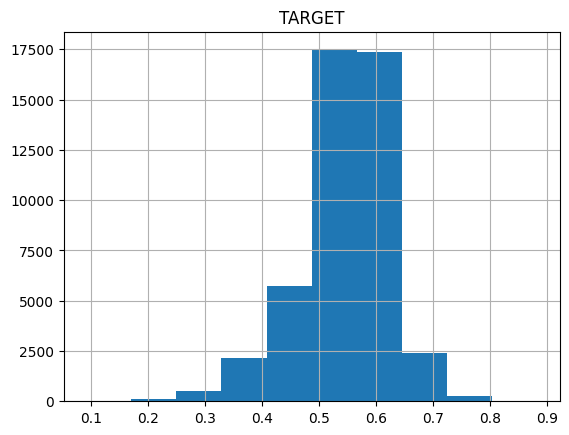

In [230]:
finale_cat.hist()

In [231]:
#Logistic Reg
lr_preds = random_search_lr.predict_proba(X_test)[:, 1]
finale_lr = pd.DataFrame({'uid': test['uid'], 'TARGET': lr_preds})


finale_lr.to_csv(r"C:\Users\aarav\OneDrive\Desktop\senior_ds_test\data\final_submission\AaravSingh_LR.csv", index=False)
finale_lr['TARGET'].head()

0    0.129735
1    0.155010
2    0.145912
3    0.167858
4    0.072350
Name: TARGET, dtype: float64

In [232]:
finale_lr.head()

,uid,TARGET
0,CMO22835242,0.129735
1,MRJ34316727,0.155010
2,UAV00534378,0.145912
3,IPQ08190402,0.167858
4,NQN84331006,0.072350


array([[<Axes: title={'center': 'TARGET'}>]], dtype=object)

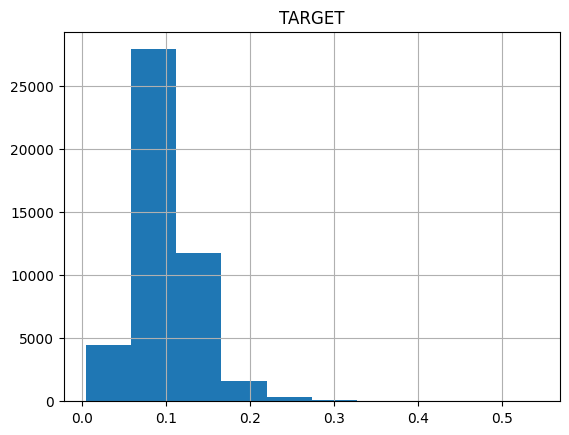

In [233]:
finale_lr.hist()

In [234]:
#Calibrate catboost 
from sklearn.calibration import CalibratedClassifierCV

calibrated_cat = CalibratedClassifierCV(random_search_cat, method='isotonic', cv='prefit')
calibrated_cat.fit(X_val, y_val)

calibrated_preds = calibrated_cat.predict_proba(X_test)[:, 1]
finale_cat_calibrated = pd.DataFrame({'uid': test['uid'], 'TARGET': calibrated_preds})


finale_cat_calibrated.to_csv(r"C:\Users\aarav\OneDrive\Desktop\senior_ds_test\data\final_submission\AaravSingh_CatBoost_Calibrated.csv", index=False)
finale_cat_calibrated['TARGET'].describe()

count    46127.000000
mean         0.104479
std          0.034087
min          0.000000
25%          0.094310
50%          0.107926
75%          0.117329
max          0.569231
Name: TARGET, dtype: float64

In [235]:
finale_cat_calibrated.head()

,uid,TARGET
0,CMO22835242,0.117329
1,MRJ34316727,0.171429
2,UAV00534378,0.107926
3,IPQ08190402,0.171429
4,NQN84331006,0.066276


array([[<Axes: title={'center': 'TARGET'}>]], dtype=object)

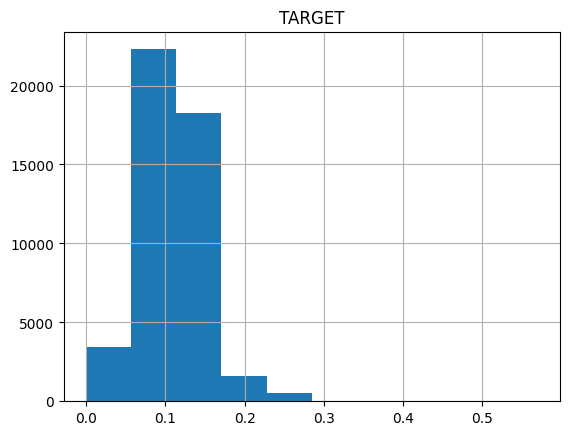

In [236]:
finale_cat_calibrated.hist()

In [247]:
#Precision Recall KS

In [241]:
from sklearn.metrics import precision_score, recall_score
from scipy.stats import ks_2samp
import numpy as np

In [248]:
threshold = 0.1

In [249]:
# CatBoost
cat_class = (val_preds >= threshold).astype(int)

print("Precision:", precision_score(y_val, cat_class).round(4))

print("Recall:", recall_score(y_val, cat_class).round(4))

ks_cat = ks_2samp(val_preds[y_val == 1], val_preds[y_val == 0]).statistic
print("KS Stat:", round(ks_cat, 4))

Precision: 0.0828
Recall: 1.0
KS Stat: 0.2782


In [250]:
# LR
lr_class = (val_preds_lr >= threshold).astype(int)

print("Precision:", precision_score(y_val, lr_class).round(4))
print("Recall:", recall_score(y_val, lr_class).round(4))

ks_lr = ks_2samp(val_preds_lr[y_val == 1], val_preds_lr[y_val == 0]).statistic
print("KS Stat:", round(ks_lr, 4))

Precision: 0.1479
Recall: 0.4566
KS Stat: 0.242


In [251]:
cat_threshold = 0.55

In [252]:
lr_threshold = 0.1

In [253]:
# CatBoost
cat_class = (val_preds >= cat_threshold).astype(int)

print("Precision:", precision_score(y_val, cat_class).round(4))

print("Recall:", recall_score(y_val, cat_class).round(4))

ks_cat = ks_2samp(val_preds[y_val == 1], val_preds[y_val == 0]).statistic
print("KS Stat:", round(ks_cat, 4))

Precision: 0.1545
Recall: 0.5006
KS Stat: 0.2782


In [254]:
# LR
lr_class = (val_preds_lr >= lr_threshold).astype(int)

print("Precision:", precision_score(y_val, lr_class).round(4))
print("Recall:", recall_score(y_val, lr_class).round(4))

ks_lr = ks_2samp(val_preds_lr[y_val == 1], val_preds_lr[y_val == 0]).statistic
print("KS Stat:", round(ks_lr, 4))

Precision: 0.1479
Recall: 0.4566
KS Stat: 0.242
